# GPU programming is cost-model first

A 1-hour course for database & systems researchers. One thesis, proven by measurement on the hardware in front of us:

> **You don't pick an algorithm and then make the chip run it. You compute the cost model first -- bytes moved, passes over memory, latency vs concurrency, where the data lives, how you access it -- and *that* selects the algorithm before you write a line.** Asymptotic optimality is not hardware-neutral; "best" is a function of the chip.

**The chip:** a single **RTX 6000 Ada** (sm_89, AD102) -- 48 GB **GDDR6** ~960 GB/s, **96 MB L2**, register file ~36 MB. It is two things at once: a **bandwidth machine** (huge throughput, but only if you keep it fed) and a **latency-hiding concurrency machine** (per-access latency is *bad*; throughput comes from running thousands of warps so a stall in one is covered by another). GPU programming is therefore not only **parallel** -- it's **concurrent**: latency forces you to always have other work in flight.

**The spine:** two sorts tell the rest of the story from two angles -- **radix** = *massive parallelism collapses the algorithm; linear-time wins*, **merge** = *the cache / access-pattern / memory-hierarchy story* -- and a production library is just a **frozen cost-model decision tree** that picks between them for you.

## Time budget -- 1 hour (~55 min content + ~5 Q&A)

| # | section | min |
|---|---|---|
| 0 | Thesis + hardware | 3 |
| 1 | Bandwidth identity | 3 |
| 2 | **Latency & how the GPU hides it** (concurrency) | 5 |
| 2b | **A thread is also a SIMD lane** (divergence trap + shuffle-sort tool) | 4 |
| 3 | **Cost model in two lines** (thrust dispatch) | 4 |
| 4 | Cache cliff -- measure at GB (right before the sorts) | 3 |
| 5 | Two sorts (framing) | 1 |
| 5a | **Radix** -- how it works + the passes-law (why linear wins) | 9 |
| 5b-i | **Merge** -- the algorithm (doubling down the hierarchy) | 5 |
| 5b-ii | **Merge** -- the optimization (register blocking + ILP) | 6 |
| 6 | Kernel is ~10% (rug pull) | 5 |
| 7 | Closing | 3 |
| - | Q&A | 5 |

content = 51 min, +5 Q&A = 56, leaving a ~4 min overrun buffer in the hour.

(SASS-diff and histogram sections were cut for time; they live in the repo as
supporting material.)

## How to read this hour: it's a guessing game

Each section pits two pieces of code and asks **which is faster, and by how much** -- then we run it, live. You will guess wrong, often, and every miss *is* the lesson: on a GPU you cannot eyeball performance; you compute the cost model.

Some demos (the pointer `chase`) are deliberate **golf** -- useless functions that isolate exactly one mechanism so you can see it in the clear. You will never write them. But you cannot *read* the code you actually ship -- GEMM, CUB's merge and radix -- without them, because that code is loops-over-loops, unrolled and register-blocked everywhere, and every line is one of these tradeoffs. **The first half builds the vocabulary; the second half spends it.**

In [1]:
%matplotlib inline
import subprocess, re, os
import matplotlib.pyplot as plt

ROOT = os.getcwd()
GPU, CPU, RADIX, MERGE, INK, CEIL = "#76b900", "#5b6770", "#0b84a5", "#c0392b", "#23272b", "#b9bfc4"
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#eef1f3", "axes.axisbelow": True})

def sh(cmd, cwd=None, timeout=900):
    r = subprocess.run(cmd, shell=True, cwd=cwd or ROOT, capture_output=True, text=True, timeout=timeout)
    return r.stdout + r.stderr

def grab(text, pat):
    m = re.search(pat, text); return float(m.group(1)) if m else float("nan")

sh("make -s -C demo1_bandwidth; make -s -C demo2_sort; make -s -C demo3_rugpull")
sh("cd demo6_mergesort && nvcc -O3 -std=c++17 -arch=sm_89 -o cub_compare cub_compare.cu && "
   "nvcc -O3 -std=c++17 -arch=sm_89 -o thrust_compare thrust_compare.cu")
sh("cd demo7_latency && nvcc -O3 -std=c++17 -arch=sm_89 -o latency latency.cu")
sh("cd demo8_divergence && nvcc -O3 -std=c++17 -arch=sm_89 -o divergence divergence.cu && "
   "nvcc -O3 -std=c++17 -arch=sm_89 -o warp_sort warp_sort.cu")
print("built.")

built.


## 1. The chip's identity is bandwidth  (~3 min)

> **Demo** `demo1_bandwidth` &middot; **in:** one ~1 GB array &middot; **out:** achieved GB/s &middot; **algorithm:** trivial vectorized streaming copy `out[i]=in[i]` (GPU) and STREAM Triad `a=b+s*c` (CPU) &middot; **why:** the simplest possible kernel, so the only thing measured is the bus -- it establishes bandwidth as the chip's identity.

A trivial streaming copy. The CPU's STREAM Triad tops out well below its (small) DRAM peak; the GPU's copy kernel saturates its (much larger) bus. The story is the *ratio*, and that the GPU number comes from a kernel you could write in your sleep.

```cpp
// float4 = 16 B/thread, fully coalesced, grid-stride
__global__ void copy(float4* out, const float4* in, size_t n) {
  for (size_t i = blockIdx.x*blockDim.x + threadIdx.x; i < n;
       i += gridDim.x*blockDim.x)            // every thread strides the array
    out[i] = in[i];
}
```

**Guess first** 🎲 -- GPU streaming copy vs CPU STREAM Triad: how many times faster? Write a number.

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>GPU copy (independent loads)</b><pre>__global__ void copy(float4* o,
          const float4* in, size_t n){
  for(size_t i=tid;i&lt;n;i+=stride)
    o[i] = in[i];
}</pre></td><td style="width:50%;vertical-align:top"><b>CPU STREAM Triad</b><pre>#pragma omp parallel for
for(size_t i=0;i&lt;n;i++)
  a[i] = b[i] + s*c[i];</pre></td></tr></table>

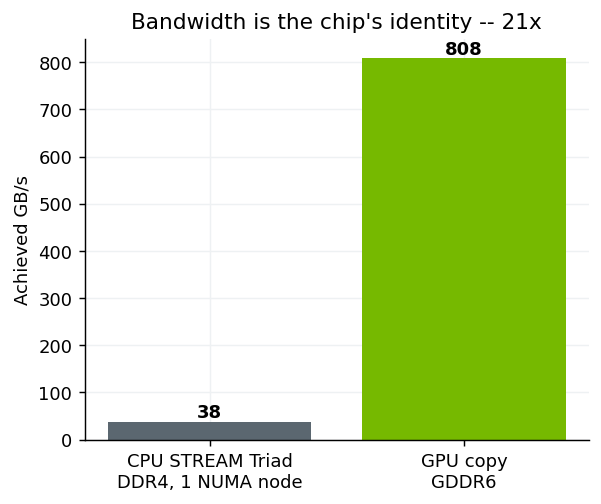

In [2]:
g = grab(sh("./stream_gpu", cwd=f"{ROOT}/demo1_bandwidth"), r"copy kernel:\s*([\d.]+)")
numa = "numactl --cpunodebind=0 --membind=0 " if sh("which numactl").strip() else ""
c = grab(sh(f"OMP_NUM_THREADS=6 OMP_PROC_BIND=close OMP_PLACES=cores {numa}./stream_cpu",
            cwd=f"{ROOT}/demo1_bandwidth"), r"triad bandwidth:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["CPU STREAM Triad\nDDR4, 1 NUMA node", "GPU copy\nGDDR6"], [c, g], color=[CPU, GPU])
ax.set_ylabel("Achieved GB/s"); ax.set_title(f"Bandwidth is the chip's identity -- {g/c:.0f}x")
for i, v in enumerate([c, g]): ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 2. The hidden half: latency, and why "18k cores" is a lie  (~5 min)

> **Demo** `demo7_latency` &middot; **in:** a 1 GB int array wired as one random permutation cycle &middot; **out:** raw latency, single-SM throughput vs warps (against the SM's issue width), and warps/SM vs register usage &middot; **algorithm:** per-thread dependent-load pointer chase on ONE SM, swept 1..32 warps, then register-heavy variants &middot; **why:** *prove* that latency hiding via oversubscription -- not "more cores" -- is the engine, and that the parallelism is *occupancy*, set by registers.

One thread chasing dependent loads to HBM waits ~230 ns / ~580 cycles. **One thread is slow** -- the GPU's per-access latency is *worse* than a CPU cache.

**What `chase` is doing, and why.** `next[]` is a random permutation wired into one giant cycle through the 1 GB array; each thread just runs `idx = next[idx]` over and over. The whole trick is that one line: the *address* of each load is the *value* the previous load returned, so the loads **cannot overlap** -- the hardware can't issue the next until the last comes back, and every access pays the full round-trip to HBM. That makes it a **latency thermometer**: the copy kernel was the opposite (independent loads, hundreds in flight -> *bandwidth*); a dependency chain has one load outstanding per thread -> *latency*. It's the one workload where latency-hiding has nothing to hide, so the raw ~230 ns shows -- then we add warps and watch the hiding switch back on. (The random *cycle*, not just random indices, is deliberate: it never short-loops and always misses the 96 MB L2. The `r[K]` registers are unrelated -- just a knob to lower occupancy for Part C.)

**Where you've already met this pattern:** a linked-list walk *is* `chase`; so is the *core* of a **graph traversal**, a **B-tree index lookup**, a **hash-join probe** -- read a value, and it tells you the next address. All of them are data-dependent, un-prefetchable, **latency-bound** access: the opposite end of the cost model from streaming. (We are *not* building a graph algorithm -- the branching and frontier machinery would bury the lesson; we keep the access pattern and drop everything else.) Which is why those DB / graph workloads live or die on the latency hiding we measure next.

Now the proof, on **one SM** so it can't be "use more cores": an Ada SM has just **4 warp schedulers** -- it can *issue* only 4 warps per clock (128 FP32 lanes = 4 warps of SIMD). If warps were cores, throughput would flatten at 4. **It doesn't.** Oversubscribe the *same* SM to 8, 16, 32 warps and throughput keeps climbing -- **32 warps (8x oversubscribed) is ~5x faster than at 4.** Those extra warps cannot be computing (there are only 4 slots); they are covering each other's 580-cycle stalls. **Warps are latency-hiding tasks you oversubscribe, not cores.**

So "18,176 CUDA cores" is not 18,176 CPUs -- it's SIMD lanes. The real parallelism is how many *warps* you keep resident = **occupancy** = register-file / (regs/thread x 32). A register-heavy kernel fits fewer warps -- and Part C **measures** the cost: 148 regs/thread caps it at **8 warps/SM**, and the *same* chase run at 8 warps is **2.7x slower** on one SM, purely from lost occupancy (the compute confound removed by measuring the light kernel at each capped warp count). That number is visible only in **`ptxas -v`** and the **profiler** -- which is why you need them.

```cpp
// each thread chases its own dependent-load cycle: latency-bound, nothing hides it
template <int K> __global__ void chase(const int* next, size_t N, int steps, int* sink) {
  size_t idx = (threadIdx.x * 2654435761ull) % N;
  int r[K];                                  // K live registers -> controls occupancy
  for (int i=0;i<steps;++i){ idx = next[idx]; for(int k=0;k<K;++k) r[k]^=(int)idx; }
}
chase<1><<<1, 32*W>>>(...);   // ONE block = ONE SM (4 schedulers); sweep W = 1..32 warps
```

**Guess first** 🎲 -- it's a *single SM* (it can issue only 4 warps/clock). Going 1 -> 32 warps on it: flat, or faster? by how much?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>1 warp on ONE SM</b><pre>chase&lt;1&gt;&lt;&lt;&lt;1,   32&gt;&gt;&gt;(...);</pre></td><td style="width:50%;vertical-align:top"><b>32 warps on the SAME SM</b><pre>chase&lt;1&gt;&lt;&lt;&lt;1, 1024&gt;&gt;&gt;(...);</pre></td></tr></table>

*(identical kernel -- only the launch width changes)*

Chip: 142 SMs x 128 FP32 lanes = 18176 "CUDA cores".
Per SM: 4 warp schedulers -> it can ISSUE only 4 warps per clock (128 lanes = 4 warps of SIMD). Naively, '4 things at once'.
Yet it holds up to 48 warps resident. Why so many more than it can run?

Part A  one thread, dependent loads: 232 ns/access (~582 cycles). one thread is slow.

Part B  ONE SM (single block), add warps past the 4 schedulers it can issue:
  warps  oversub   Maccess/s   speedup
     1      0x         117.2     1.0x
     2      0x         200.2     1.7x
     4      1x         395.8     3.4x
     8      2x         763.4     6.5x
    16      4x        1451.4     12.4x
    32      8x        2115.5     18.1x
  -> 4 warps already fills the 4 schedulers; 32 warps (8x oversubscribed) is 5.3x FASTER.
     Those extra warps cannot be using cores -- there are only 4 -- they are
     hiding the 582-cycle latency. Warps are TASKS you oversubscribe, not cores.


Part C  registers -> occupancy -> (measured) latency hiding on one

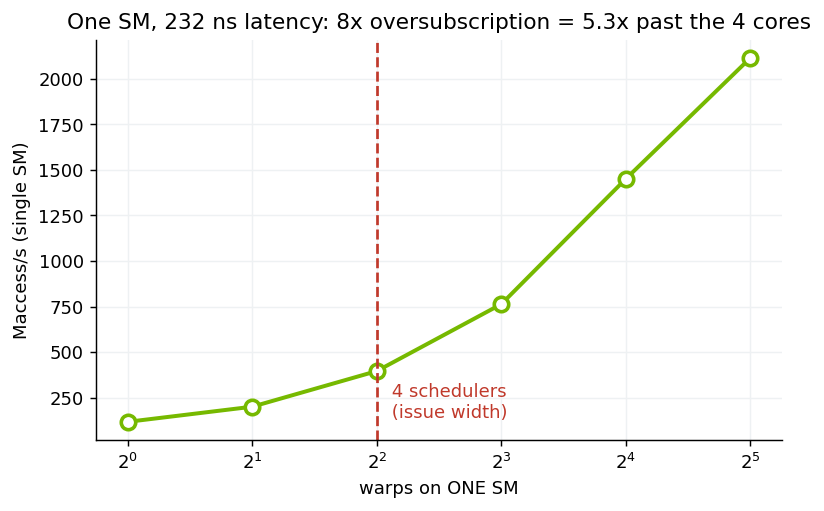

In [3]:
out = sh("./latency", cwd=f"{ROOT}/demo7_latency"); print(out)
lat = grab(out, r"([\d.]+)\s*ns/access")
rows = re.findall(r"^\s*(\d+)\s+[\d.]+x\s+([\d.]+)\s+[\d.]+x\s*$", out, re.M)
warps = [int(a) for a, _ in rows]; thru = [float(b) for _, b in rows]
fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(warps, thru, "o-", color=GPU, lw=2.2, ms=8, mfc="white", mew=2)
ax.axvline(4, ls="--", color=MERGE); ax.text(4.2, thru[0], " 4 schedulers\n (issue width)", color=MERGE, va="bottom")
ax.set_xscale("log", base=2); ax.set_xlabel("warps on ONE SM"); ax.set_ylabel("Maccess/s (single SM)")
over = (thru[-1]/thru[2]) if len(thru) > 2 else 0    # 32 warps vs 4 warps
ax.set_title(f"One SM, {lat:.0f} ns latency: 8x oversubscription = {over:.1f}x past the 4 cores")
plt.show()

## 2b. The other face: a "thread" is also a SIMD lane  (~4 min)

In section 2 a "thread" was a *task* you oversubscribe to **hide** latency. Inside a warp it's the opposite: 32 "threads" are **one SIMD unit** -- 32 lanes running the *same instruction* in lockstep. A data-dependent branch doesn't fork 32 independent threads; the warp executes *every* path some lane takes, and a data-dependent loop runs until the **slowest** lane finishes while the rest idle.

The proof, total work held constant: every warp does the same number of iterations -- we only change whether the 32 lanes share them *evenly* or *unevenly* (one branch on the lane id). Same work; the uneven version is **~2x slower**, purely because the warp moves at its slowest lane.

**Guess first** 🎲 -- both kernels do the **same total work per warp**; A spreads it evenly across the 32 lanes, B unevenly (lane L does L units -- a branch on the lane id). Same speed, or not? by how much?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>A -- even (no divergence)</b><pre>int iters = 16 * step;   // every lane equal</pre></td><td style="width:50%;vertical-align:top"><b>B -- uneven (a branch)</b><pre>int iters = lane * step; // lanes 0..31 differ</pre></td></tr></table>

Same total work per warp (avg ~16 lanes' worth), only the *spread* differs:
  uniform  (all 32 lanes do equal work):   1.805 ms
  skewed   (lanes do 0..31 -- a branch):   3.455 ms   (1.9x slower)

  The 32 'threads' are one SIMD unit: the warp runs at its slowest lane.
  Your scalar per-thread code never showed this -- it's a warp-level cost.



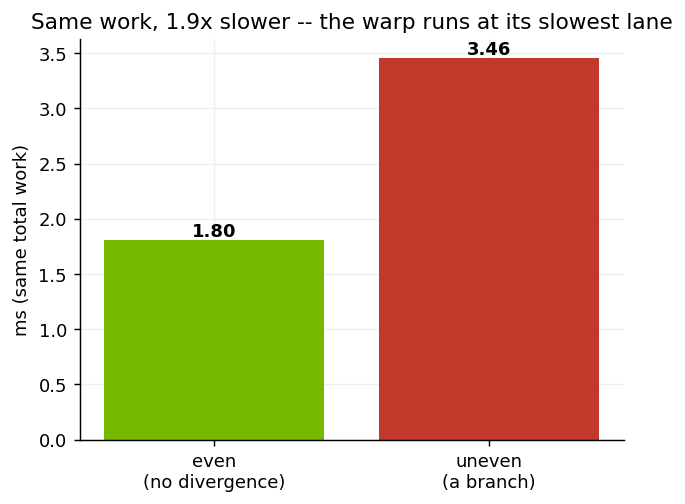

In [4]:
out = sh("./divergence", cwd=f"{ROOT}/demo8_divergence"); print(out)
u = grab(out, r"equal work\):\s*([\d.]+)"); v = grab(out, r"a branch\):\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(5.4, 4))
ax.bar(["even\n(no divergence)", "uneven\n(a branch)"], [u, v], color=[GPU, MERGE])
ax.set_ylabel("ms (same total work)"); ax.set_title(f"Same work, {v/u:.1f}x slower -- the warp runs at its slowest lane")
for i, val in enumerate([u, v]): ax.text(i, val, f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
plt.show()

This is the leaky abstraction CUDA's language papers over: a "thread" is **sometimes an independent task** (when enough warps hide latency -- section 2) and **sometimes a SIMD lane** (when the warp moves in lockstep -- here). "Parallelism" is sometimes *simultaneous* (independent warps) and sometimes *hidden* (one stalls, another runs). You write the same scalar per-thread code for both -- and you must know which it actually is.

**Lockstep isn't only a tax -- it's also a tool.** If 32 lanes always run the same instruction, a lane can *read a neighbour lane's register directly* with a shuffle (`__shfl`) -- no shared memory, no `__syncthreads`, no data-dependent `if`. The lanes stop being a hazard and start **cooperating**: they run a fixed, **data-oblivious** sorting **network** (branchless min/max compare-exchanges), so every lane runs the identical instruction stream and the lockstep is free.

Below, 32 lanes sort their 32 values using *only* register-to-register shuffles. It is the **odd-even network we show in full in §5b** (`net_sort`, which *is* CUB's `StableOddEvenSort`) -- here walked **across the warp's 32 lanes**, there walked **down one thread's registers**. Same network, the two faces of a thread -- so we keep the listing for §5b and just run it here.

In [5]:
print(sh("./warp_sort", cwd=f"{ROOT}/demo8_divergence"))

32 lanes sorting 32 values via __shfl only -- no shared mem, no divergence: [PASS]
  this is net_sort's odd-even network (demo6), turned ACROSS lanes -- lanes cooperating.



## 3. The cost model, in two lines of user code  (~4 min, the hook)

> **Demo** `demo6_mergesort/thrust_compare` &middot; **in:** 2^28 random int32 &middot; **out:** runtime of `thrust::sort` with a default vs a custom comparator &middot; **algorithm:** `thrust::sort`, which dispatches to radix or merge by key/comparator *type* &middot; **why:** the cost-model decision is already baked into the highest-level API -- the hook.

We've now seen what the chip *is* -- a bandwidth machine (§1), latency hidden by concurrency (§2), SIMD lanes (§2b). The highest-level GPU sort API -- `thrust::sort` -- *already encodes choosing for it*. Its dispatch (`thrust/system/cuda/detail/sort.h`, `can_use_primitive_sort`) picks at **compile time**:

```cpp
// arithmetic key (int/float...) AND default less/greater  -> RADIX  (cub::DeviceRadixSort)
// custom comparator, or non-arithmetic key                -> MERGE  (cub::DeviceMergeSort)
```

These two calls sort the *same data into the same order* -- the only difference is a comparator whose type happens to mean `a < b` -- yet one is several times slower, because its type blocks the radix path. **The cost model, triggered by a type, invisible to the user.**

```cpp
struct MyLess { __device__ bool operator()(int a, int b) const { return a < b; } };

thrust::sort(d.begin(), d.end());             // -> radix  (arithmetic key + default less)
thrust::sort(d.begin(), d.end(), MyLess());   // -> merge  (custom comparator TYPE blocks radix)
```

**Guess first** 🎲 -- `thrust::sort(x)` vs `thrust::sort(x, MyLess())`. Same data, same ascending order, a comparator that *means* `a < b`. Same speed? If not, which way, and how much?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>thrust::sort(x)</b><pre>thrust::sort(d.begin(), d.end());</pre></td><td style="width:50%;vertical-align:top"><b>thrust::sort(x, MyLess())</b><pre>struct MyLess {
  bool operator()(int a,int b){return a&lt;b;}
};
thrust::sort(d.begin(), d.end(), MyLess());</pre></td></tr></table>

n=2^28 (268M keys)
  thrust::sort(x)           -> radix :   18.942 ms  [PASS]
  thrust::sort(x, MyLess()) -> merge :   54.552 ms  [PASS]
  one custom comparator cost you 2.9x -- the cost model, by type.



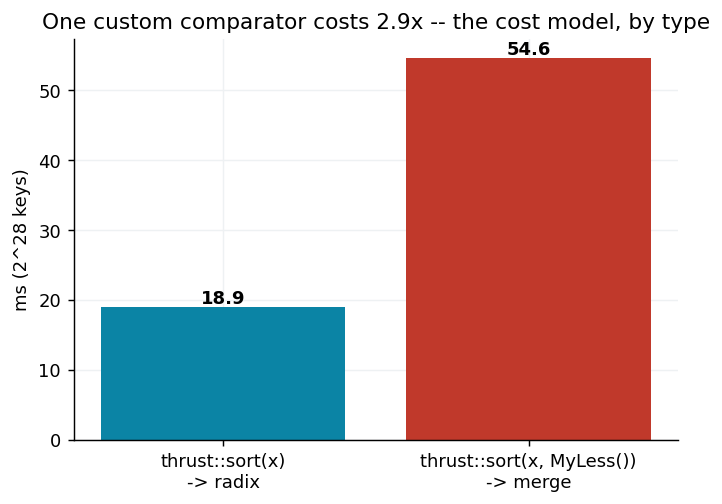

In [6]:
out = sh("./thrust_compare 28 6", cwd=f"{ROOT}/demo6_mergesort"); print(out)
r = grab(out, r"-> radix :\s*([\d.]+)"); m = grab(out, r"-> merge :\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["thrust::sort(x)\n-> radix", "thrust::sort(x, MyLess())\n-> merge"], [r, m], color=[RADIX, MERGE])
ax.set_ylabel("ms (2^28 keys)"); ax.set_title(f"One custom comparator costs {m/r:.1f}x -- the cost model, by type")
for i, v in enumerate([r, m]): ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## 4. Before we measure the sorts: the cache cliff -- so measure at GB scale  (~3 min)

> **Demo** `demo2_sort/v0_naive` &middot; **in:** 2^24..2^27 random int32 keys &middot; **out:** sort throughput vs array size &middot; **algorithm:** naive bitonic sort (one global-memory kernel per compare-swap stage) &middot; **why:** the same kernel across sizes exposes the L2 cliff -- proof a sub-cache benchmark lies, so measure at >= 1 GB.

That `thrust` gap -- and *every* number in the two sorts next -- is only trustworthy at the right size. Run the *same naive sort kernel* across sizes: below 96 MB the array lives in L2 and throughput is ~4x higher than reality; cross the L2 and you fall off a cliff to true HBM-bound speed. **Any benchmark that fits in cache is lying to you** -- so everything from here on (the two sorts) runs at >= 1 GB.

```cpp
// naive bitonic: one kernel launch PER stage, every compare-swap hits global memory
__global__ void stage(int* a, int n, int j, int k) {
  int i = blockIdx.x*blockDim.x + threadIdx.x, ixj = i ^ j;
  if (ixj > i) {
    bool asc = (i & k) == 0;
    if ((a[i] > a[ixj]) == asc) { int t=a[i]; a[i]=a[ixj]; a[ixj]=t; }
  }
}
```

**Guess first** 🎲 -- the *same* sort kernel on 64 MB vs 256 MB of keys: same throughput, or not? and why would it differ?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>64 MB (fits in 96 MB L2)</b><pre>bitonic_sort(d, 1&lt;&lt;24);</pre></td><td style="width:50%;vertical-align:top"><b>256 MB (exceeds L2)</b><pre>bitonic_sort(d, 1&lt;&lt;26);</pre></td></tr></table>

*(identical kernel -- only the array size changes)*

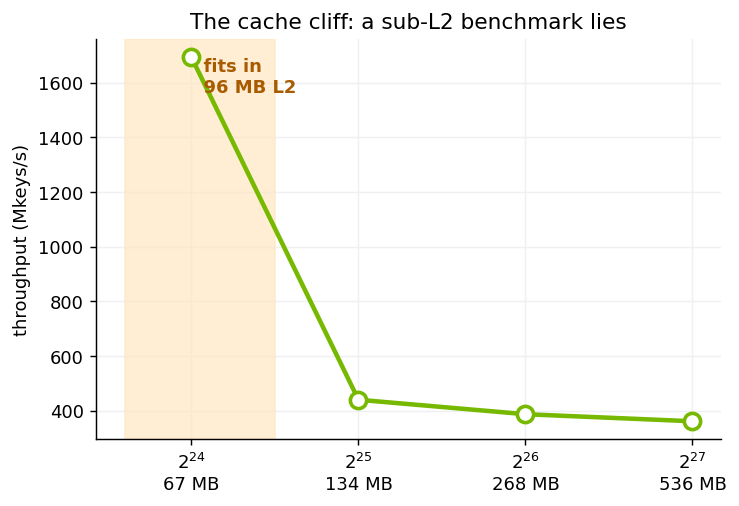

In [7]:
sizes = [24, 25, 26, 27]
mk = [grab(sh(f"./v0_naive {s} 5", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*Mkeys/s") for s in sizes]
fig, ax = plt.subplots(figsize=(6.2, 4)); x = range(len(sizes))
ax.plot(x, mk, "o-", color=GPU, lw=2.5, ms=9, mfc="white", mew=2)
ax.axvspan(-0.4, 0.5, color="#ffe7c2", alpha=0.7)
ax.text(0, mk[0], "  fits in\n  96 MB L2", va="top", color="#a85b00", fontweight="bold")
ax.set_xticks(list(x)); ax.set_xticklabels([f"$2^{{{s}}}$\n{2**s*4//10**6} MB" for s in sizes])
ax.set_ylabel("throughput (Mkeys/s)"); ax.set_title("The cache cliff: a sub-L2 benchmark lies")
plt.show()

## 5. Two sorts, two truths about the chip  (framing ~1 min)

Why ship *both*? Because there's no single best sort -- the cost model picks the game. The two algorithms illuminate the two halves of "what is a GPU."

### 5a. Radix -- *massive parallelism collapses the algorithm; linear time wins*  (~9 min)

> **Demo** `demo6_mergesort/radix_passes` (how it works) + `demo2_sort` (v0->v4) + `cub_compare` &middot; **in:** tiny keys, then 2^26 / 2^28 random int32 &middot; **out:** the array sorting digit-by-digit; then per-version runtime and CUB radix vs merge at 1 GB &middot; **why:** radix makes *no comparisons* -- its cost is the number of digit-passes, and on a bandwidth machine that's why it wins.

On a CPU you're taught O(n log n) comparison sort is optimal, and you ignore radix for its constants. The GPU inverts that cost model: with near-perfect data-parallelism the per-element work is free, so **only passes over memory count**. Radix makes **no comparisons at all** -- it reads a *digit* of each key and stably buckets by it, one digit at a time. After `key_bits / digit_bits` passes the whole key is sorted. Watch it happen:

**Recap -- how radix sorts without ever comparing.** Each pass is a **stable counting sort on one digit**: (1) **histogram** the digit values, (2) **exclusive prefix-sum** the histogram to get each bucket's start, (3) **scatter** each key to its bucket. Repeat low digit -> high digit; LSD stability means earlier passes survive. That histogram->scan->scatter is exactly what `cub::DeviceRadixSort` runs as GPU kernels per digit -- and the only thing the cost model counts is **how many passes**.

In [8]:
# tiny LSD radix that dumps the array after each digit-pass -- watch it become sorted.
sh("nvcc -O3 -std=c++17 -arch=sm_89 -o /tmp/rp radix_passes.cu", cwd=f"{ROOT}/demo6_mergesort")
print(sh("/tmp/rp", cwd=f"{ROOT}/demo6_mergesort"))

LSD radix, n=24, 8-bit keys, 2-bit digits -> 4 passes. [] marks the digit each pass reads:

input (unsorted)           011010[10] 100110[00] 111110[01] 100000[11] 101110[00] 110010[00] 000000[00] 000101[01] 111111[01] 100100[11] 110010[10] 011010[11] 111110[01] 101010[01] 100010[10] 100101[01] 011101[11] 101001[10] 111000[00] 100101[00] 101011[00] 010111[01] 101001[11] 100011[10] 
after pass 1 (digit 0)     100110[00] 101110[00] 110010[00] 000000[00] 111000[00] 100101[00] 101011[00] 111110[01] 000101[01] 111111[01] 111110[01] 101010[01] 100101[01] 010111[01] 011010[10] 110010[10] 100010[10] 101001[10] 100011[10] 100000[11] 100100[11] 011010[11] 011101[11] 101001[11]  (sorted by low bits so far)
after pass 2 (digit 1)     0000[00]00 1110[00]00 1000[00]11 1001[00]11 1001[01]00 0001[01]01 1001[01]01 1010[01]10 0111[01]11 1010[01]11 1001[10]00 1011[10]00 1100[10]00 1111[10]01 1111[10]01 1010[10]01 0110[10]10 1100[10]10 1000[10]10 0110[10]11 1010[11]00 1111[11]01 0101[11]01 1000[11]10  (sor

**Guess first** 🎲 -- a *world-class* comparison sort (CUB merge) vs CUB radix, both at 1 GB: which wins, and by how much?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>CUB merge (comparison)</b><pre>cub::DeviceMergeSort::SortKeys(
   tmp, sz, d, n, less);</pre></td><td style="width:50%;vertical-align:top"><b>CUB radix</b><pre>cub::DeviceRadixSort::SortKeys(
   tmp, sz, d_in, d_out, n);</pre></td></tr></table>

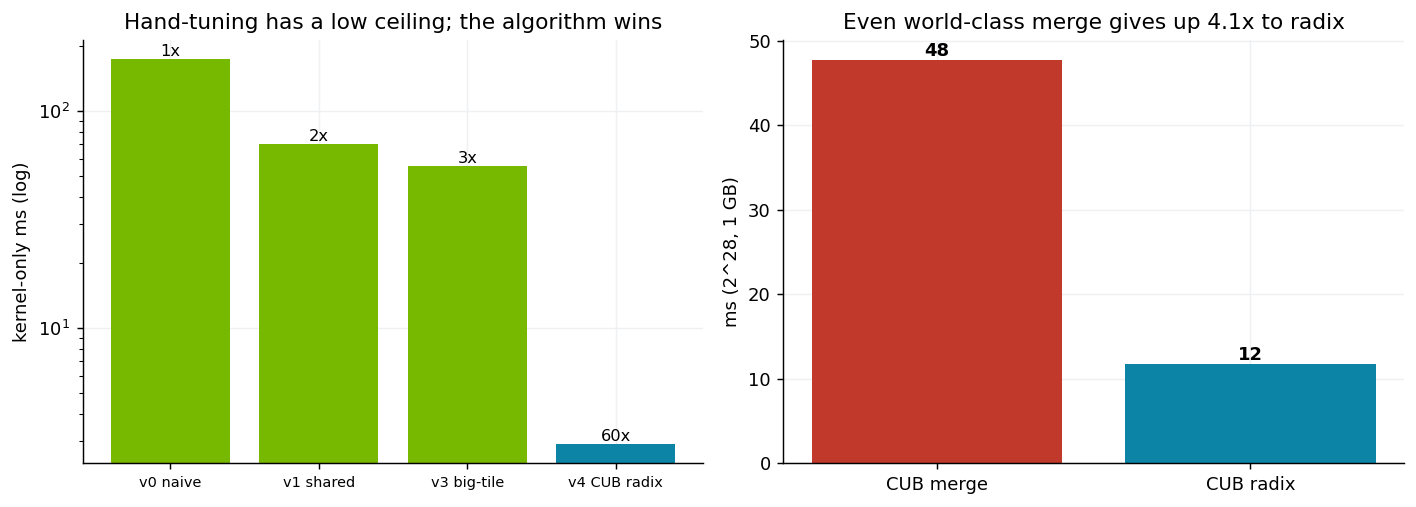

passes-law: radix ~4 passes vs merge ~18 passes -> predicted 4.5x; measured 4.1x. The speedup IS the pass ratio, not magic.


In [9]:
ARC = [("v0_naive","v0 naive"),("v1_shared","v1 shared"),("v3_multiblock","v3 big-tile"),("v4_cub","v4 CUB radix")]
ms = {lbl: grab(sh(f"./{b} 26 10", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*ms") for b, lbl in ARC}
base = ms["v0 naive"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
bars = a1.bar(list(ms), list(ms.values()), color=[GPU, GPU, GPU, RADIX]); a1.set_yscale("log")
a1.set_ylabel("kernel-only ms (log)"); a1.set_title("Hand-tuning has a low ceiling; the algorithm wins")
for b, v in zip(bars, ms.values()): a1.text(b.get_x()+b.get_width()/2, v, f"{base/v:.0f}x", ha="center", va="bottom", fontsize=9)
a1.tick_params(axis="x", labelsize=8)
out = sh("./cub_compare 28 6", cwd=f"{ROOT}/demo6_mergesort")
cm = grab(out, r"merge sort :\s*([\d.]+)"); cr = grab(out, r"radix sort :\s*([\d.]+)")
a2.bar(["CUB merge", "CUB radix"], [cm, cr], color=[MERGE, RADIX]); a2.set_ylabel("ms (2^28, 1 GB)")
a2.set_title(f"Even world-class merge gives up {cm/cr:.1f}x to radix")
for i, v in enumerate([cm, cr]): a2.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()
rp = 32 // 8               # radix: 32-bit keys, 8-bit digits -> 4 passes
mp = (28 - 11) + 1         # merge @2^28, TILE=2^11: 17 device-merge passes + 1 block-sort = 18
print(f"passes-law: radix ~{rp} passes vs merge ~{mp} passes -> predicted {mp/rp:.1f}x; "
      f"measured {cm/cr:.1f}x. The speedup IS the pass ratio, not magic.")

**That is the whole radix lesson, quantified.** Both sorts are *pass-bound* (each pass streams all of memory once -- §1's bandwidth is the ceiling). Radix's cost is `key_bits / digit_bits` passes -- **~4** for 32-bit keys, *independent of n*. Merge's cost is `log2(n/TILE)` passes -- **~18** at 2^28. The measured ~4x isn't a constant-factor tuning win; it's `18/4` -- **fewer passes over memory.** That's why "O(n) beats O(n log n)" here is not a CPU heresy but the cost model doing its job: on a bandwidth machine where per-element work is free, the algorithm with fewer memory passes wins, full stop.

### 5b-i. Merge -- the algorithm: doubling down the memory hierarchy  (~5 min)

> **Demo** `demo6_mergesort/merge_passes` &middot; **in:** tiny random int32 &middot; **out:** the array after every pass &middot; **algorithm:** a CUB-faithful parallel merge sort &middot; **why:** make the parallel merge sort concrete -- watch the sorted runs double, each level in a bigger tier of memory.

Merge is the **general** sort -- any comparator, where radix can't go. Its speed on a GPU isn't about the algorithm; it's about **where the data lives**. First, a recap of what the parallel merge sort actually does.

**Recap -- a parallel merge sort is just DOUBLING, walked down the hierarchy.** Classic merge sort starts with sorted runs of length 1 and repeatedly merges adjacent pairs: runs of 1 -> 2 -> 4 -> ... -> n. The GPU does exactly that, but each level of doubling happens in a *different, larger* tier of memory, because the runs outgrow each tier:

1. **Per thread, in REGISTERS:** each thread loads `IPT` keys and sorts them with `net_sort` -> a sorted run of length `IPT`, never leaving registers.
2. **Per block, through SHARED memory:** the block's threads merge their runs pairwise (`IPT` -> `2·IPT` -> ... -> `TILE`), so each block emits one sorted **tile**.
3. **Across the device, through GLOBAL memory:** a sequence of kernel passes merges sorted tiles pairwise (`TILE` -> `2·TILE` -> ... -> `n`) -- these are the `log2(n/TILE)` passes the cost model counts. Each pass streams *all* of memory once, so merge's speed ceiling is just **§1's bandwidth ÷ passes** (the §5a roofline) -- everything below is about hitting it.

Each individual merge is parallel via **MergePath** (co-rank): to fill output slot *k*, one binary search finds the unique split of the two input runs that feeds it, so every thread merges an independent, equal-size chunk -- no thread waits on another. *Same algorithm at every level; only the tier the data lives in changes.* Watch the runs double on a tiny input:

In [10]:
# tiny n=64 run that dumps the array after EVERY pass -- watch runs double 1->4->16->32->64
sh("nvcc -O3 -std=c++17 -arch=sm_89 -o /tmp/mp merge_passes.cu", cwd=f"{ROOT}/demo6_mergesort")
print(sh("/tmp/mp", cwd=f"{ROOT}/demo6_mergesort"))

Parallel merge sort, n=64, IPT=4, BLOCK=4, TILE=16 -- watch runs DOUBLE:

0. input               [input ] runs of  1: | 15| 92| 21| 86| 83| 47| 87| 79| 88| 61| 58| 31|  8| 17| 62| 30| 66| 72| 83| 18| 96| 40| 95| 51|  8| 68| 43| 27| 30| 78| 51| 40| 16| 63|  5| 76| 16| 27| 65| 60| 79| 61|  4|  2| 52| 21| 54| 98| 12| 42|  9| 19|  7| 83|  0| 67|  0| 65| 32| 32| 50| 27| 53| 32|  (each run sorted)
1. per-thread net_sort [REG   ] runs of  4: | 15 21 86 92| 47 79 83 87| 31 58 61 88|  8 17 30 62| 18 66 72 83| 40 51 95 96|  8 27 43 68| 30 40 51 78|  5 16 63 76| 16 27 60 65|  2  4 61 79| 21 52 54 98|  9 12 19 42|  0  7 67 83|  0 32 32 65| 27 32 50 53|  (each run sorted)
2. block_sort (tile)   [SHARED] runs of 16: |  8 15 17 21 30 31 47 58 61 62 79 83 86 87 88 92|  8 18 27 30 40 40 43 51 51 66 68 72 78 83 95 96|  2  4  5 16 16 21 27 52 54 60 61 63 65 76 79 98|  0  0  7  9 12 19 27 32 32 32 42 50 53 65 67 83|  (each run sorted)
3. device merge run=16 [GLOBAL] runs of 32: |  8  8 15 17 18 21 27 30 3

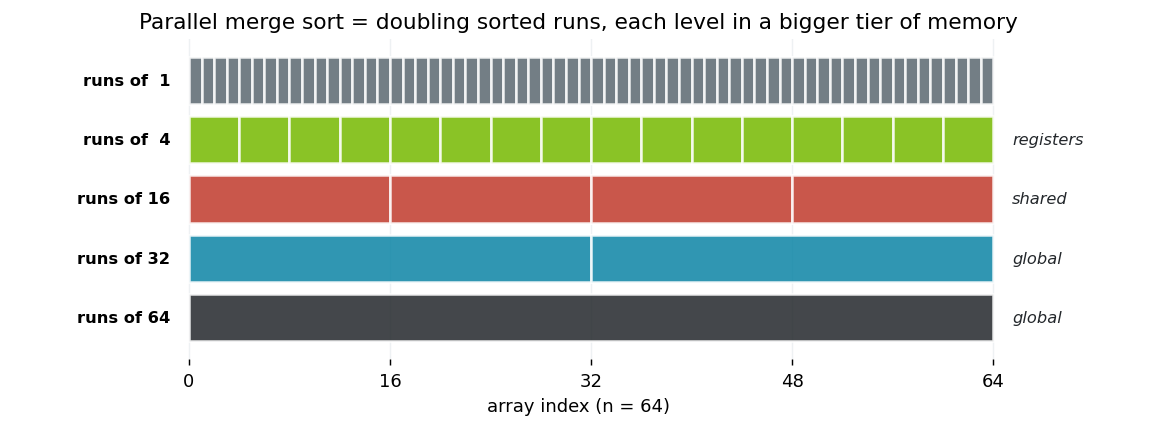

In [11]:
# the same doubling as a picture: each row is one pass; bars are sorted runs.
stages = [("input",      1,  CPU),   ("per-thread net_sort", 4,  GPU),
          ("block_sort", 16, MERGE), ("device merge", 32, RADIX), ("device merge", 64, INK)]
tiers  = ["",  "registers", "shared", "global", "global"]
fig, ax = plt.subplots(figsize=(9, 3.4)); N = 64
for row, (name, rl, col) in enumerate(stages):
    y = len(stages) - 1 - row
    for x0 in range(0, N, rl):
        ax.add_patch(plt.Rectangle((x0, y - 0.4), rl, 0.8, facecolor=col,
                     edgecolor="white", lw=1.4, alpha=0.85))
    ax.text(-1.5, y, f"runs of {rl:>2}", ha="right", va="center", fontsize=9, fontweight="bold")
    ax.text(N + 1.5, y, tiers[row], ha="left", va="center", fontsize=9, color=INK, style="italic")
ax.set_xlim(-14, N + 12); ax.set_ylim(-0.7, len(stages) - 0.3)
ax.set_yticks([]); ax.set_xticks([0, 16, 32, 48, 64]); ax.set_xlabel("array index (n = 64)")
ax.set_title("Parallel merge sort = doubling sorted runs, each level in a bigger tier of memory")
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()

### 5b-ii. Merge -- the optimization: register blocking & ILP  (~6 min)

We have a *correct* parallel merge sort. Now the one *hardware* lever that makes it fast -- and it's the same latency story as §2, moved inside a thread.

**The hardware lever: register blocking** -- dialed by one number, **`ITEMS_PER_THREAD` (IPT)**: how many keys each thread holds and sorts in registers (level 1) before touching shared/global. The surface reason is "registers are the fastest, and chip-wide the *largest* (~36 MB), on-chip memory." But that can't be the whole story -- IPT=1 uses registers too. The deep reason it keeps paying at GB scale, where a 96 MB L2 should hide every latency, is **ILP**.

```cpp
// register blocking: each thread holds IPT keys and sorts them IN REGISTERS first.
template <int IPT> __global__ void block_sort(int* g, ...) {
  int keys[IPT];                                 // <-- IPT independent registers
  for (int i=0;i<IPT;++i) keys[i] = g[base + tid*IPT + i];   // IPT independent loads
  net_sort(keys);                                // sort this thread's IPT keys in registers
  /* ...then merge across threads through shared memory (level 2)... */
}
```

`net_sort` is the **same odd-even network from §2b** -- a fixed, branchless min/max compare-exchange schedule -- run *down one thread's `IPT` registers* instead of *across the warp's 32 lanes*. It is **exactly CUB's `StableOddEvenSort`** (`cub/thread/thread_sort.cuh`; CUB keeps an `if`-swap to stay stable and carry payloads, we use branchless min/max, keys-only). This is where §2b's **divergence tax gets paid off**: a network is **data-oblivious** -- the comparisons don't depend on the values -- so there is no data-dependent branch to diverge on, and all 32 lanes run it in lockstep. And "branchless" isn't even something *you* must write: a data-oblivious `if`-swap has nothing to diverge on, so `ptxas` **predicates it to the identical SASS**. Proof -- compile the network both ways and diff the cubin:

```cpp
__device__ void net_sort(int (&a)[IPT]) {        // branchless compare-exchanges only
  for (int i = 0; i < IPT; ++i)
    for (int j = i & 1; j + 1 < IPT; j += 2) {
      int lo = min(a[j], a[j+1]), hi = max(a[j], a[j+1]);   // no `if` -> no divergence
      a[j] = lo; a[j+1] = hi;
    }
}
```

In [12]:
# PROOF that the network's branchlessness is a compiler guarantee, not a hand-opt:
# build net_sort as min/max vs as a naive `if`-swap (-DNETBRANCHY) and compare the SASS.
def block_sort_sass(flag):
    sh(f"nvcc -O3 -std=c++17 -arch=sm_89 -DIPT=8 {flag} -cubin -o /tmp/np.cubin merge_ablation.cu",
       cwd=f"{ROOT}/demo6_mergesort")
    sass = sh("cuobjdump -sass -fun _Z10block_sortPim /tmp/np.cubin", cwd=f"{ROOT}/demo6_mergesort")
    return [l.split('*/')[1].split(';')[0].strip() for l in sass.splitlines() if '/*' in l and ';' in l]
bl, br = block_sort_sass(""), block_sort_sass("-DNETBRANCHY")
nbra = lambda xs: sum('BRA' in i for i in xs)
print(f"  branchless min/max : {len(bl):4d} SASS instrs, {nbra(bl)} divergent BRA")
print(f"  naive   if-swap    : {len(br):4d} SASS instrs, {nbra(br)} divergent BRA")
print(f"\n  the `if`-swap added {len(br)-len(bl)} instructions and {nbra(br)-nbra(bl)} branches -> ptxas predicated it")
print("  to the same code. Divergence isn't 'having an if'; it's data-DEPENDENT control")
print("  flow -- which a data-oblivious network, by construction, has none of.")

  branchless min/max :  576 SASS instrs, 41 divergent BRA
  naive   if-swap    :  576 SASS instrs, 41 divergent BRA

  the `if`-swap added 0 instructions and 0 branches -> ptxas predicated it
  to the same code. Divergence isn't 'having an if'; it's data-DEPENDENT control
  flow -- which a data-oblivious network, by construction, has none of.


**ILP = instruction-level parallelism** -- the thing you already know from superscalar / out-of-order CPUs: *independent* instructions that can be in flight at the same time. §2 hid memory latency with many **warps** (parallelism *across* threads). Register blocking hides it with ILP *inside one thread*: give a thread `IPT` independent items and the unrolled load loop becomes `IPT` independent loads the scheduler issues **back-to-back, all outstanding at once** -- one thread overlapping `IPT` memory latencies (this memory-op flavour of ILP is **MLP**, memory-level parallelism). That is why register blocking climbs even when the cache is huge: the win isn't caching, it's **keeping more memory operations in flight**. You can read it straight off the SASS:

In [13]:
# ASSEMBLY proof of ILP/MLP: count the independent global loads (LDG.E) the compiler
# emits per thread in block_sort, for IPT=1 vs IPT=8.
import re
for ipt in (1, 8):
    sh(f"nvcc -O3 -std=c++17 -arch=sm_89 -DIPT={ipt} -cubin -o /tmp/ba{ipt}.cubin merge_ablation.cu",
       cwd=f"{ROOT}/demo6_mergesort")
    sass = sh(f"cuobjdump -sass -fun _Z10block_sortPim /tmp/ba{ipt}.cubin", cwd=f"{ROOT}/demo6_mergesort")
    loads = [l.split('*/')[1].split(';')[0].strip() for l in sass.splitlines() if "LDG.E" in l]
    print(f"--- IPT={ipt}: {len(loads)} independent global load(s) per thread in block_sort ---")
    for l in loads: print("   ", l)
print("\nIPT=1: ONE load, its result is needed at once -> the thread STALLS on that latency.")
print("IPT=8: EIGHT loads issued back-to-back, none consumed yet -> 8 latencies overlapped")
print("       by a single thread. That is ILP/MLP -- latency hiding without any extra warps.")

--- IPT=1: 1 independent global load(s) per thread in block_sort ---
    @!P0 LDG.E R12, [R10.64]


--- IPT=8: 8 independent global load(s) per thread in block_sort ---
    @!P0 LDG.E R0, [R4.64+0x4]
    @!P1 LDG.E R7, [R4.64]
    @!P4 LDG.E R6, [R4.64+0xc]
    @!P3 LDG.E R9, [R4.64+0x8]
    @!P5 LDG.E R8, [R4.64+0x14]
    @!P6 LDG.E R11, [R4.64+0x10]
    @!P2 LDG.E R15, [R4.64+0x18]
    @!P0 LDG.E R10, [R4.64+0x1c]

IPT=1: ONE load, its result is needed at once -> the thread STALLS on that latency.
IPT=8: EIGHT loads issued back-to-back, none consumed yet -> 8 latencies overlapped
       by a single thread. That is ILP/MLP -- latency hiding without any extra warps.


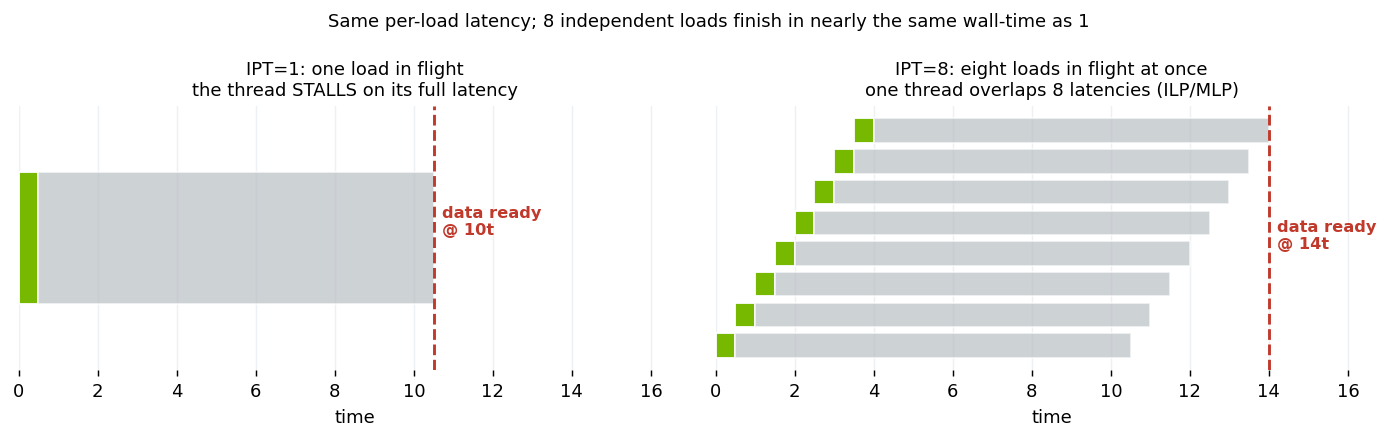

In [14]:
# picture it: 1 load in flight (latency fully exposed) vs IPT loads in flight (overlapped).
# each row is one in-flight load: short green = issue, long grey = memory latency.
LAT, ISS = 10.0, 0.5
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, n, title in [(a1, 1, "IPT=1: one load in flight\nthe thread STALLS on its full latency"),
                     (a2, 8, "IPT=8: eight loads in flight at once\none thread overlaps 8 latencies (ILP/MLP)")]:
    finish = 0
    for k in range(n):
        t0 = k * ISS                                   # back-to-back issue
        ax.add_patch(plt.Rectangle((t0, k), ISS, 0.8, facecolor=GPU, edgecolor="white"))
        ax.add_patch(plt.Rectangle((t0 + ISS, k), LAT, 0.8, facecolor=CEIL, edgecolor="white", alpha=0.7))
        finish = max(finish, t0 + ISS + LAT)
    ax.axvline(finish, ls="--", color=MERGE, lw=1.6)
    ax.text(finish + 0.2, n / 2, f"data ready\n@ {finish:.0f}t", va="center", fontsize=9, color=MERGE, fontweight="bold")
    ax.set_xlim(0, 17); ax.set_ylim(-0.4, max(n, 1) + 0.2); ax.set_yticks([])
    ax.set_title(title, fontsize=10); ax.set_xlabel("time")
    for s in ax.spines.values(): s.set_visible(False)
fig.suptitle("Same per-load latency; 8 independent loads finish in nearly the same wall-time as 1", fontsize=10)
plt.tight_layout(); plt.show()

**Guess first** 🎲 -- merge sort with 1 vs 16 items/thread (register blocking). Does pushing work into registers even matter at GB scale, on a chip with a 96 MB L2?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>1 item / thread</b><pre>nvcc -DIPT=1  merge_ablation.cu</pre></td><td style="width:50%;vertical-align:top"><b>16 items / thread (register-blocked)</b><pre>nvcc -DIPT=16 merge_ablation.cu</pre></td></tr></table>

*(same source -- only ITEMS_PER_THREAD changes)*

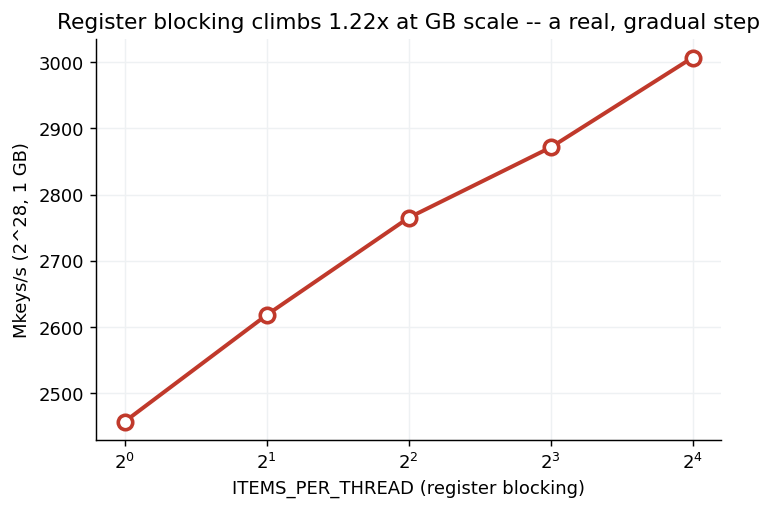

NOT flat: more items/thread -> more independent loads in flight (ILP/MLP), so the
climb survives even past the 96 MB L2. The lever is concurrency-in-a-thread, not cache.


In [15]:
# register-blocking ablation: rebuild merge sort with IPT 1..16 and sort 1 GB
res = {}
for ipt in [1, 2, 4, 8, 16]:
    sh(f"cd demo6_mergesort && nvcc -O3 -std=c++17 -arch=sm_89 -DIPT={ipt} -o /tmp/m{ipt} merge_ablation.cu")
    res[ipt] = grab(sh(f"/tmp/m{ipt} 28 6", cwd=f"{ROOT}/demo6_mergesort"), r"([\d.]+)\s*Mkeys/s")
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(list(res), list(res.values()), "o-", color=MERGE, lw=2.2, ms=8, mfc="white", mew=2)
ax.set_xscale("log", base=2); ax.set_xlabel("ITEMS_PER_THREAD (register blocking)")
ax.set_ylabel("Mkeys/s (2^28, 1 GB)")
lo, hi = res[1], res[16]
ax.set_title(f"Register blocking climbs {hi/lo:.2f}x at GB scale -- a real, gradual step")
plt.show()
print("NOT flat: more items/thread -> more independent loads in flight (ILP/MLP), so the")
print("climb survives even past the 96 MB L2. The lever is concurrency-in-a-thread, not cache.")

## 6. The kernel is ~10%  (~5 min)

> **Demo** `demo3_rugpull` &middot; **in:** 2^20 keys wrapped in a per-iteration allocate/copy/sort/copy/free loop &middot; **out:** per-iteration ms for naive vs pool vs graph &middot; **algorithm:** the same v3 sort, with cudaMalloc vs cudaMallocAsync vs a captured CUDA graph &middot; **why:** the kernel is unchanged across all three -- it shows allocation/orchestration, not the kernel, dominates.

Take the best hand-rolled sort and wrap it the way a query stage actually runs: allocate, copy in, sort, copy out, free -- every iteration. The kernel never changes, yet per-iteration time swings wildly. `cudaMalloc`/`cudaFree` are synchronous driver calls; a stream-ordered pool (`cudaMallocAsync`) and a CUDA graph claw the time back -- none of it by touching the kernel.

```cpp
for (int i = 0; i < N; ++i) {
  cudaMalloc(&d_in, bytes);  cudaMalloc(&d_out, bytes);   // synchronous: serialize device
  cudaMemcpyAsync(d_in, h, bytes, H2D, s);
  sort(d_in, n, s);
  cudaMemcpyAsync(h, d_in, bytes, D2H, s);
  cudaFree(d_in);  cudaFree(d_out);                       // synchronous too
}
// the fix, same kernel: cudaMallocAsync(&d,bytes,s) / cudaFreeAsync(d,s)  (+ a CUDA graph)
```

**Guess first** 🎲 -- the *identical* sort kernel, but `cudaMalloc`/`Free` every iteration vs `cudaMallocAsync`: how much does *just the allocator* cost?

<table style="width:100%"><tr><td style="width:50%;vertical-align:top"><b>cudaMalloc per iteration</b><pre>cudaMalloc(&amp;d, bytes);
sort(d, n, s);
cudaFree(d);</pre></td><td style="width:50%;vertical-align:top"><b>cudaMallocAsync (pool)</b><pre>cudaMallocAsync(&amp;d, bytes, s);
sort(d, n, s);
cudaFreeAsync(d, s);</pre></td></tr></table>

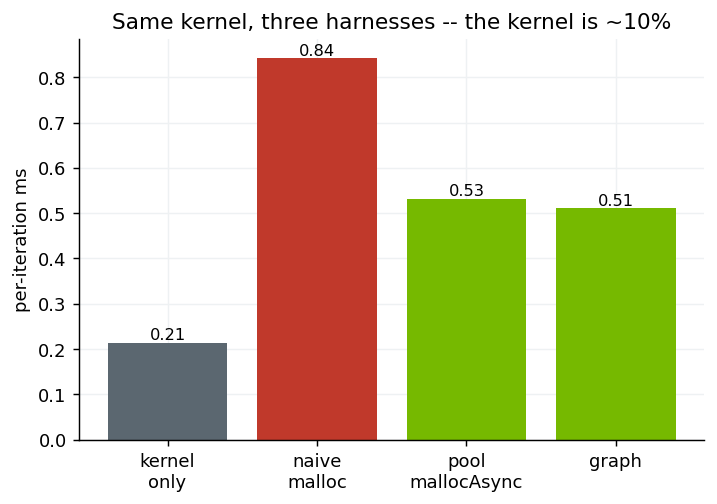

In [16]:
H = ["naive", "pool", "graph"]
outs = {h: sh(f"./{h}_harness 20 200", cwd=f"{ROOT}/demo3_rugpull") for h in H}
pit = {h: grab(outs[h], r"per-iter\s*:\s*([\d.]+)") for h in H}
kon = grab(outs["naive"], r"kernel-only\s*:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.bar(["kernel\nonly", "naive\nmalloc", "pool\nmallocAsync", "graph"], [kon, pit["naive"], pit["pool"], pit["graph"]],
       color=[CPU, MERGE, GPU, GPU])
ax.set_ylabel("per-iteration ms"); ax.set_title("Same kernel, three harnesses -- the kernel is ~10%")
for i, v in enumerate([kon, pit["naive"], pit["pool"], pit["graph"]]): ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.show()

## Closing: the library is a frozen cost-model decision tree  (~3 min)

Everything pointed one way. The chip is a **bandwidth machine you keep fed by hiding latency with concurrency**; on top of that, `thrust::sort` picks radix-vs-merge by *type* at compile time, and CUB ships *both* sorts (and both an atomic and a sort-based histogram). The experts didn't find *the* answer -- they encoded the **question** and a chooser, because the right choice is a function of the input and the chip.

So the one sentence to leave with: **compute the cost model first.** Bytes moved, passes, latency vs concurrency, where the data lives, how you access it -- that arithmetic selects the algorithm, tells you when to stop tuning, and tells you which library call to make. On a GPU, that is the program; the kernel is a detail.

**The payoff.** Open CUB's `block_merge_sort.cuh` now. The per-thread register sorting-network, the shared-memory `MergePath` merge, the `ITEMS_PER_THREAD` blocking -- you just watched each one in isolation and guessed at its cost. You can *read* it. That is what an hour of golf buys: not that you can write GEMM, but that you can read the cost-model decisions in the code you already depend on.